# First deep learning approach second challenge

In [1]:
import sys
import os
sys.path.append(os.path.abspath("../")) #Add parent directory

# Libraries

In [2]:
import torch
import numpy as np
from modules.data_loader import get_data_loaders
from modules.models_pretrained import SkinLesionClassifier
from modules.train import train_model
from modules.utils import calculate_accuracy
from modules.visualize_aug import visualize_dataloader

# Connect to GPU

In [3]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

True
NVIDIA GeForce RTX 4060 Laptop GPU
Device: cuda


# Hyperparameters

In [4]:
batch_size = 64
num_epochs = 10
learning_rate = 0.001
train_dir = r"C:\Users\User\Desktop\UDG_old_pc\UDG\Subjects\Computer_Aided_Diagnosis\Labs\Datasets\train\train".replace("\\", "/")
val_dir = r"C:\Users\User\Desktop\UDG_old_pc\UDG\Subjects\Computer_Aided_Diagnosis\Labs\Datasets\val\val".replace("\\", "/")

# Load data

In [5]:
train_loader, val_loader = get_data_loaders(train_dir, val_dir, batch_size)

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

class_train = train_loader.dataset.classes
class_val = val_loader.dataset.classes

print(f"Train classes {class_train}")
print(f"Val classes: {class_val}")

Train classes ['nevus', 'others']
Val classes: ['nevus', 'others']


Type of images: <class 'torch.Tensor'>
Type of labels: <class 'torch.Tensor'>
Type of paths: <class 'tuple'>


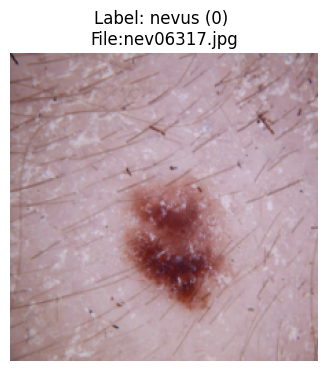

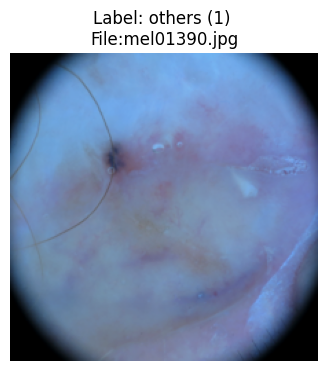

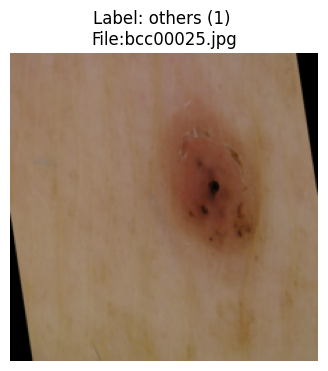

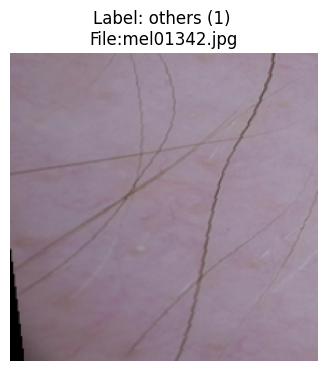

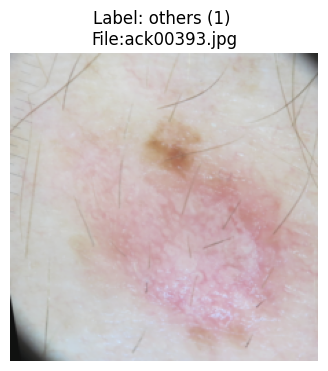

In [6]:
visualize_dataloader(train_loader, mean, std, 5)

# Load model

In [7]:
#Initialize model
model = SkinLesionClassifier(num_classes=2)

c:\Users\User\GitHub_Projects\CAD_DL\CADx-Project\dl_env_f\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\GitHub_Projects\CAD_DL\CADx-Project\dl_env_f\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Loss and optimizer

In [8]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

## Train the model

In [9]:
model = train_model(model,  train_loader, val_loader, criterion, optimizer, num_epochs, device)

#Evaluate the model

accuracy = calculate_accuracy(model, val_loader, device)

print(f"Val accuracy: {accuracy:.2f}%")

Epoch 1/10, Training Loss: 0.5095
Epoch 2/10, Training Loss: 0.4558
Epoch 3/10, Training Loss: 0.4436
Epoch 4/10, Training Loss: 0.4651
Epoch 5/10, Training Loss: 0.4395
Epoch 6/10, Training Loss: 0.4272
Epoch 7/10, Training Loss: 0.4198
Epoch 8/10, Training Loss: 0.4140
Epoch 9/10, Training Loss: 0.4143
Epoch 10/10, Training Loss: 0.4083
Val accuracy: 83.06%


In [10]:
print("Test")

Test
